# Toolkit para el parcial — celdas listas para copiar y pegar

Cada sección (§A, §B, …) corresponde a un tipo de ejercicio de la `guia_rapida.md`. Las celdas usan una **serie demo** marcada con `# <-- TU SERIE ACÁ`: copiá la celda al notebook del parcial y reemplazá solo esa línea.

- §0 Setup e imports (correr siempre primero)
- §A Regresión: tendencia + estacionalidad
- §B ARMA / ARIMA
- §C Dos series: CCF + regresión con lag
- §D Espacio de estados (UnobservedComponents)
- §E Extras: residuos, train/test + append, regresión + ARMA combinados

## §0 — Setup

In [1]:
# §0a: imports estándar del curso
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astsadata as astsa
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

In [2]:
# §0b: funciones útiles del curso (si el enunciado ya las trae, usá las de él)

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, ccf, basefmt='k')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel('LAG')
    ax.set_ylabel('CCF')
    return ax

def periodogram(x, sampling_frequency=1):
    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    plt.plot(f, P)
    plt.xlabel('Frequency')
    plt.ylabel('Power')

def spectrum(x, sampling_frequency=1, nfreq=10):
    n = x.size
    nfreq = np.minimum(nfreq, round(n/2))
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1]
    return pd.DataFrame({'Frecuencia': f[index[0:nfreq]], 'Potencia': P[index[0:nfreq]]})

print('funciones listas')

funciones listas


## §A — Tipo A: regresión con tendencia + estacionalidad
*(demo: `cardox`, CO₂ mensual)*

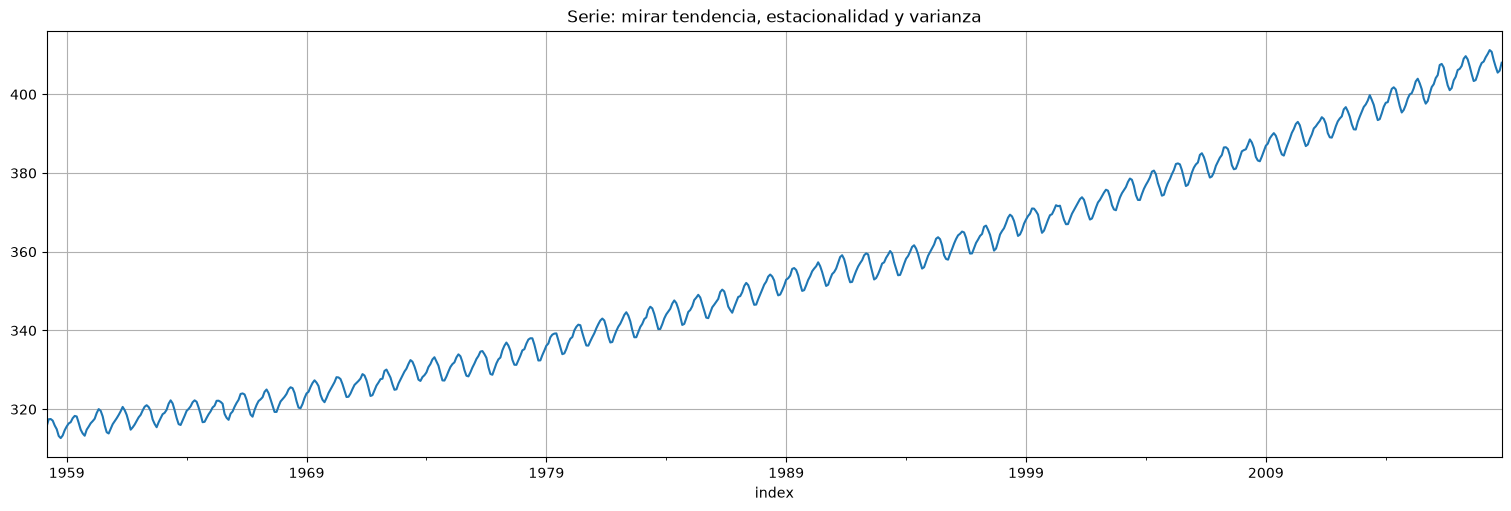

In [3]:
# §A1: cargar, graficar, describir
x = astsa.cardox.squeeze()      # <-- TU SERIE ACÁ (.squeeze() si es DataFrame de 1 columna)
fs = 12                         # <-- obs por unidad de tiempo (mensual=12, semanal=52, trimestral=4)

x.plot(title='Serie: mirar tendencia, estacionalidad y varianza');

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    314.4597      0.245   1280.898      0.000     313.978     314.942
t              0.0654      0.002     41.964      0.000       0.062       0.068
I(t ** 2)   8.787e-05   2.07e-06     42.416      0.000    8.38e-05    9.19e-05

R2 lineal     = 0.9776 | AIC = 4138.4
R2 cuadratico = 0.9935 | AIC = 3231.7


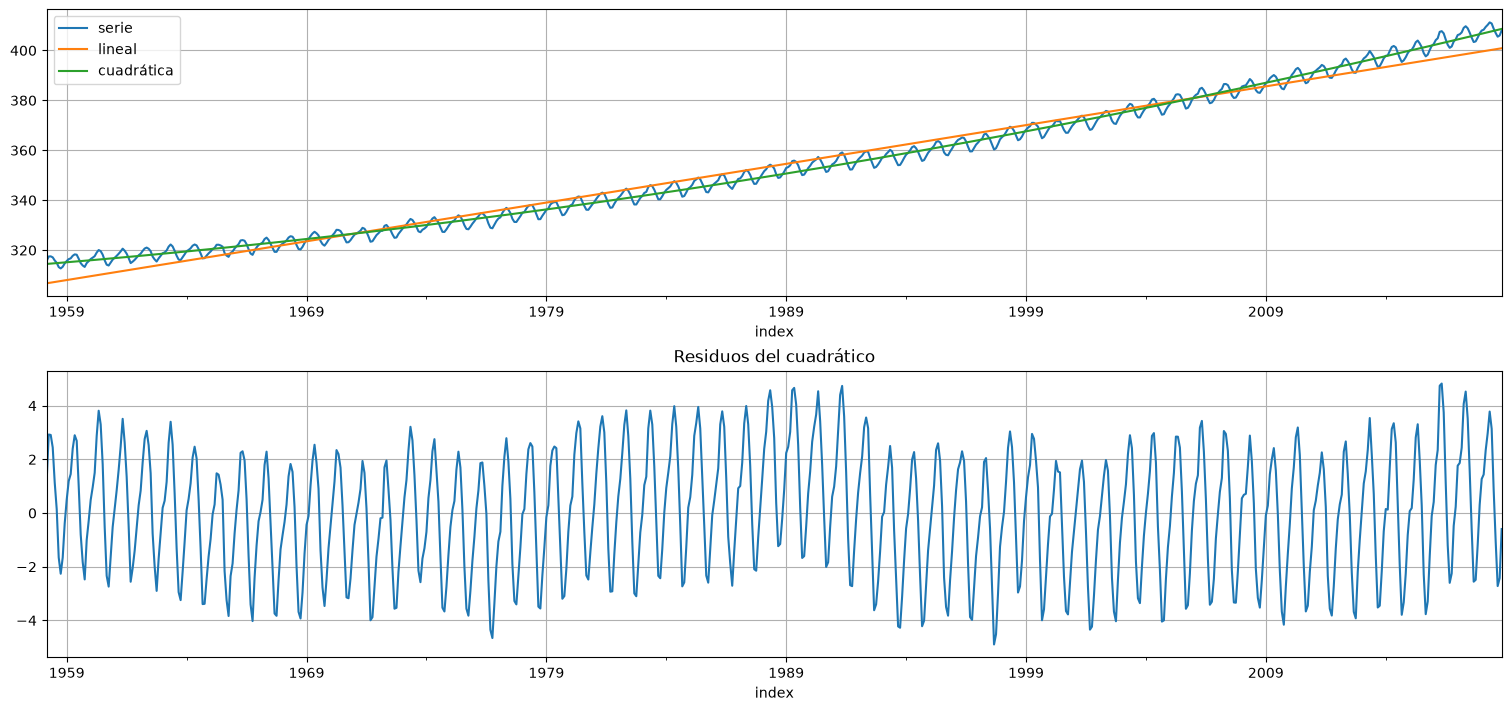

In [4]:
# §A2: tendencia lineal y cuadrática + comparación
n = len(x)
df = pd.DataFrame({'y': x.values, 't': np.arange(n)})

fit_lin = ols('y ~ t', data=df).fit()
fit_cuad = ols('y ~ t + I(t**2)', data=df).fit()
print(fit_cuad.summary().tables[1])
print()
print(f'R2 lineal     = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')
print(f'R2 cuadratico = {fit_cuad.rsquared:.4f} | AIC = {fit_cuad.aic:.1f}')

fig, axs = plt.subplots(2, 1, figsize=(15, 7))
x.plot(ax=axs[0], label='serie')
pd.Series(fit_lin.fittedvalues.values, index=x.index).plot(ax=axs[0], label='lineal')
pd.Series(fit_cuad.fittedvalues.values, index=x.index).plot(ax=axs[0], label='cuadrática')
axs[0].legend()
pd.Series(fit_cuad.resid.values, index=x.index).plot(ax=axs[1], title='Residuos del cuadrático');

,Frecuencia,Potencia
0,1.004115,6.851430
1,0.987654,0.587196
2,0.032922,0.503610
3,2.008230,0.276524
4,1.991770,0.226001
5,1.020576,0.177790


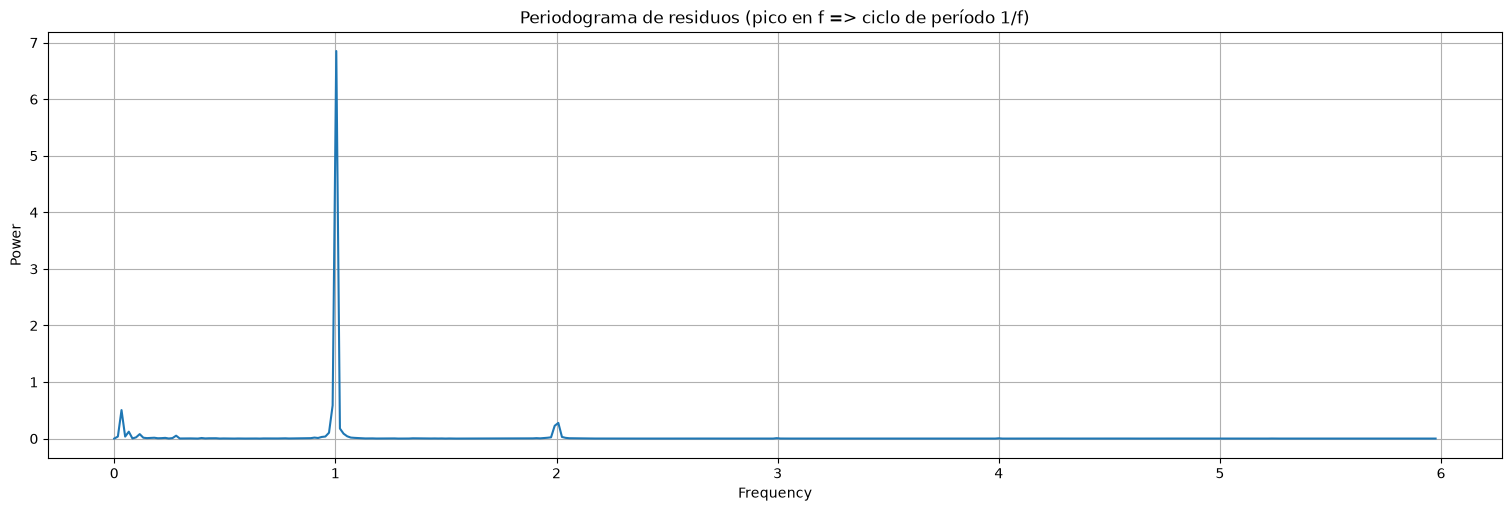

In [5]:
# §A3: periodograma de los residuos -> frecuencias dominantes
res = fit_cuad.resid            # <-- residuos del último ajuste
periodogram(res, sampling_frequency=fs)
plt.title('Periodograma de residuos (pico en f => ciclo de período 1/f)')
spectrum(res, sampling_frequency=fs, nfreq=6)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    314.4273      0.085   3704.297      0.000     314.261     314.594
t              0.0655      0.001    121.541      0.000       0.064       0.067
I(t ** 2)   8.786e-05   7.16e-07    122.668      0.000    8.65e-05    8.93e-05
sin1           1.6597      0.040     41.338      0.000       1.581       1.739
cos1           2.2824      0.040     56.926      0.000       2.204       2.361
sin2           0.0494      0.040      1.232      0.218      -0.029       0.128
cos2          -0.7856      0.040    -19.582      0.000      -0.864      -0.707

Modelo final: R2 = 0.9992 | AIC = 1686.6


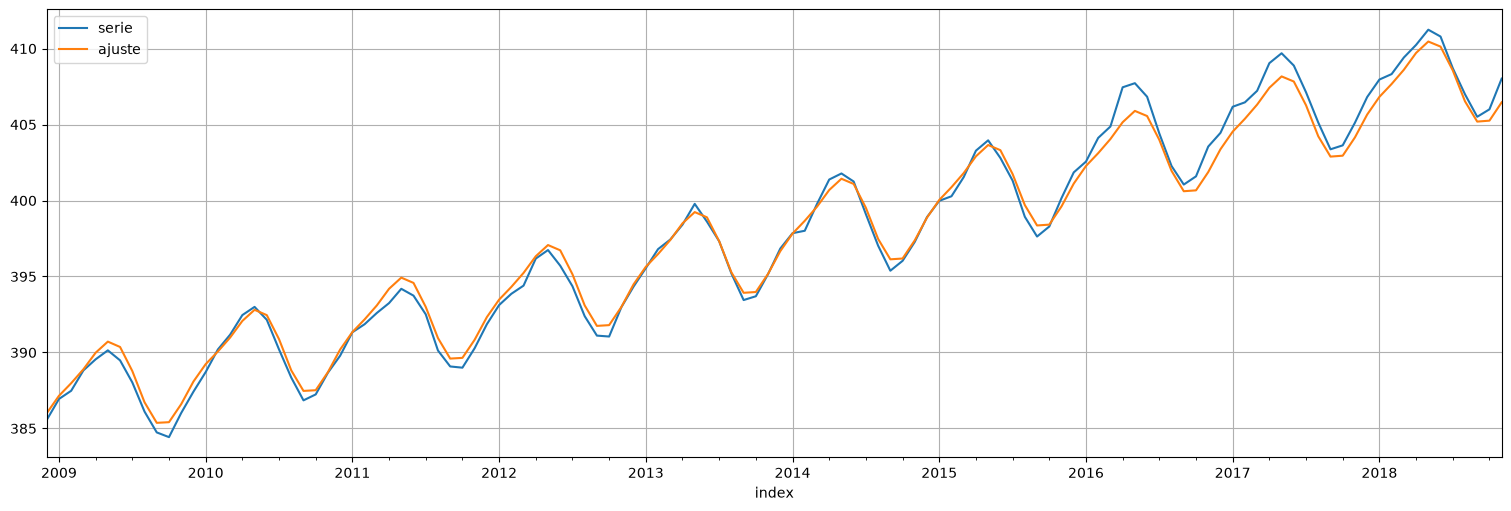

In [6]:
# §A4: agregar armónicos en las frecuencias del periodograma y reajustar
# frecuencia anual con datos mensuales: sin/cos(2*pi*t/12); armónico doble: 2*2*pi*t/12
df['sin1'] = np.sin(2*np.pi*df['t']/12)
df['cos1'] = np.cos(2*np.pi*df['t']/12)
df['sin2'] = np.sin(2*np.pi*2*df['t']/12)
df['cos2'] = np.cos(2*np.pi*2*df['t']/12)

fit_full = ols('y ~ t + I(t**2) + sin1 + cos1 + sin2 + cos2', data=df).fit()
print(fit_full.summary().tables[1])

# Mirar p-valores: eliminar los términos NO significativos y reajustar (decilo en la respuesta)
fit_full = ols('y ~ t + I(t**2) + sin1 + cos1 + cos2', data=df).fit()
print()
print(f'Modelo final: R2 = {fit_full.rsquared:.4f} | AIC = {fit_full.aic:.1f}')

ajuste = pd.Series(fit_full.fittedvalues.values, index=x.index)
ax = x[-120:].plot(label='serie')
ajuste[-120:].plot(ax=ax, label='ajuste')
ax.legend();

In [7]:
# §A5: ALTERNATIVA a los armónicos -> dummies mensuales con C(mes)
# (útil cuando el patrón estacional no es sinusoidal; usa más parámetros)
df['mes'] = x.index.month       # requiere índice con fechas (PeriodIndex/DatetimeIndex)
fit_dum = ols('y ~ t + I(t**2) + C(mes)', data=df).fit()
print(f'R2 armónicos = {fit_full.rsquared:.4f} | AIC = {fit_full.aic:.1f}')
print(f'R2 dummies   = {fit_dum.rsquared:.4f} | AIC = {fit_dum.aic:.1f}')
print()
print(fit_dum.summary().tables[1])

R2 armónicos = 0.9992 | AIC = 1686.6
R2 dummies   = 0.9992 | AIC = 1692.5

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      314.4822      0.127   2467.323      0.000     314.232     314.732
C(mes)[T.2]      0.6278      0.140      4.494      0.000       0.354       0.902
C(mes)[T.3]      1.3830      0.139      9.940      0.000       1.110       1.656
C(mes)[T.4]      2.5269      0.139     18.161      0.000       2.254       2.800
C(mes)[T.5]      2.9584      0.139     21.263      0.000       2.685       3.232
C(mes)[T.6]      2.2540      0.139     16.200      0.000       1.981       2.527
C(mes)[T.7]      0.6333      0.139      4.552      0.000       0.360       0.906
C(mes)[T.8]     -1.5105      0.139    -10.856      0.000      -1.784      -1.237
C(mes)[T.9]     -3.2062      0.139    -23.044      0.000      -3.479      -2.933
C(mes)[T.10]    -3.2959      0.139

## §B — Tipo B: ARMA / ARIMA
*(demo: `gdp` trimestral con transformación ∇log)*

Media de la transformada: 0.0078  (si es != 0, la serie tiene drift)


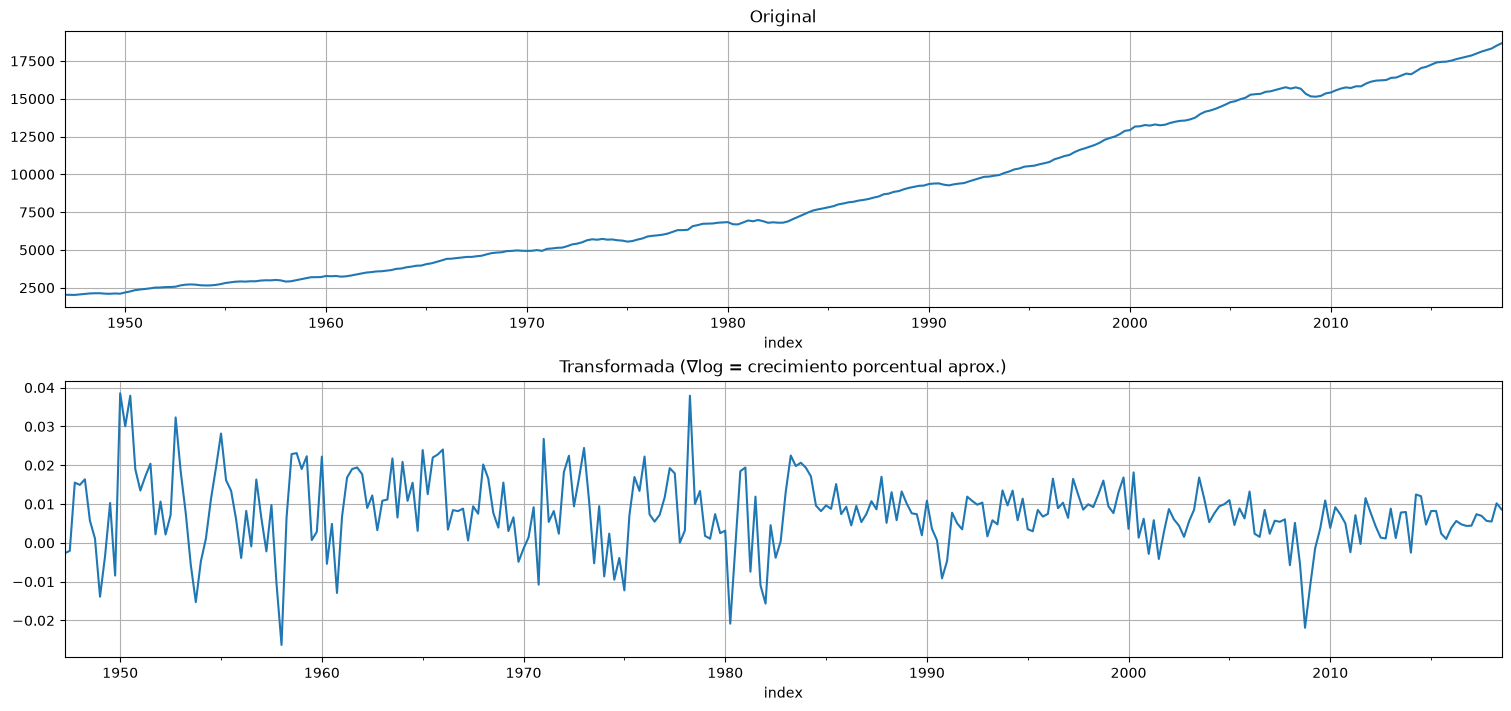

In [8]:
# §B1: ¿estacionaria? -> transformar si hace falta
z = astsa.gdp.squeeze()         # <-- TU SERIE ACÁ

# Menú de transformaciones (elegir según el caso):
#   tendencia            -> z.diff().dropna()
#   varianza creciente   -> np.log(z)
#   crecimiento %        -> np.log(z).diff().dropna()   (= ∇log)
w = np.log(z).diff().dropna()   # <-- LA TRANSFORMACIÓN ELEGIDA

fig, axs = plt.subplots(2, 1, figsize=(15, 7))
z.plot(ax=axs[0], title='Original')
w.plot(ax=axs[1], title='Transformada (∇log = crecimiento porcentual aprox.)')
print(f'Media de la transformada: {w.mean():.4f}  (si es != 0, la serie tiene drift)')

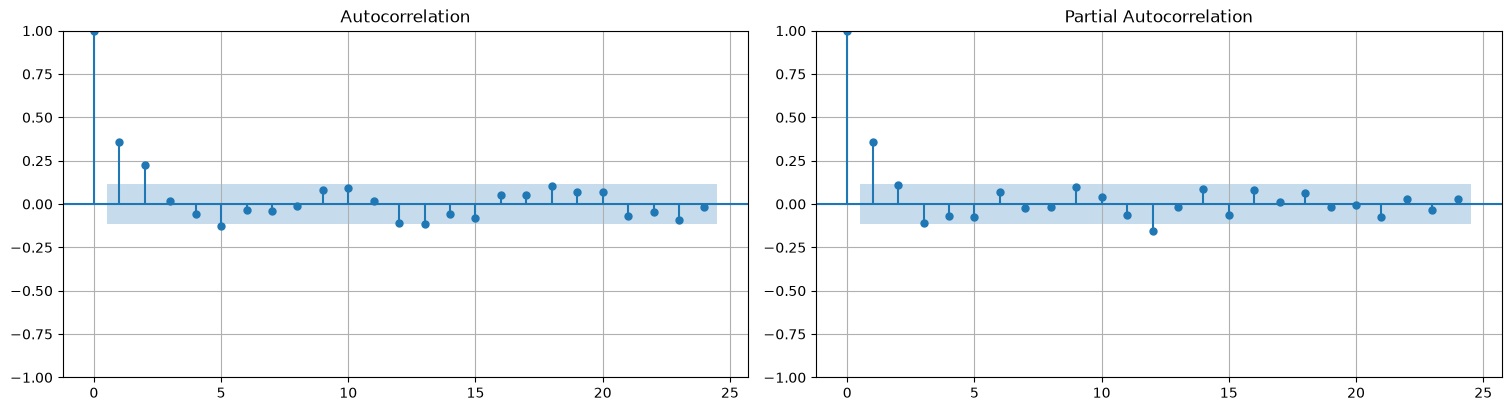

In [9]:
# §B2: ACF y PACF para identificar (p, q)
# AR(p): ACF decae, PACF corta en p | MA(q): ACF corta en q, PACF decae | ARMA: ambas decaen
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(w, lags=24, bartlett_confint=False, ax=axs[0])
plot_pacf(w, lags=24, ax=axs[1]);

In [10]:
# §B3: ajustar candidatos y comparar por AIC
ordenes = [(1, 0, 0), (2, 0, 0), (0, 0, 1), (0, 0, 2), (1, 0, 1)]   # <-- tus candidatos
aics = {}
for orden in ordenes:
    try:
        aics[str(orden)] = ARIMA(w, order=orden).fit().aic
    except Exception:
        aics[str(orden)] = np.nan
print(pd.Series(aics).sort_values())

modelo = ARIMA(w, order=(1, 0, 1)).fit()   # <-- EL ELEGIDO (menor AIC + coefs significativos)
print()
print(modelo.summary().tables[1])

(0, 0, 2)   -1897.985102
(2, 0, 0)   -1896.598750
(1, 0, 1)   -1894.976635
(1, 0, 0)   -1894.931003
(0, 0, 1)   -1884.176758
dtype: float64

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.001      8.386      0.000       0.006       0.010
ar.L1          0.5423      0.125      4.330      0.000       0.297       0.788
ma.L1         -0.2006      0.139     -1.438      0.150      -0.474       0.073
sigma2      7.535e-05   4.53e-06     16.636      0.000    6.65e-05    8.42e-05


      lb_stat  lb_pvalue
10  15.267076   0.122624
20  31.282956   0.051564


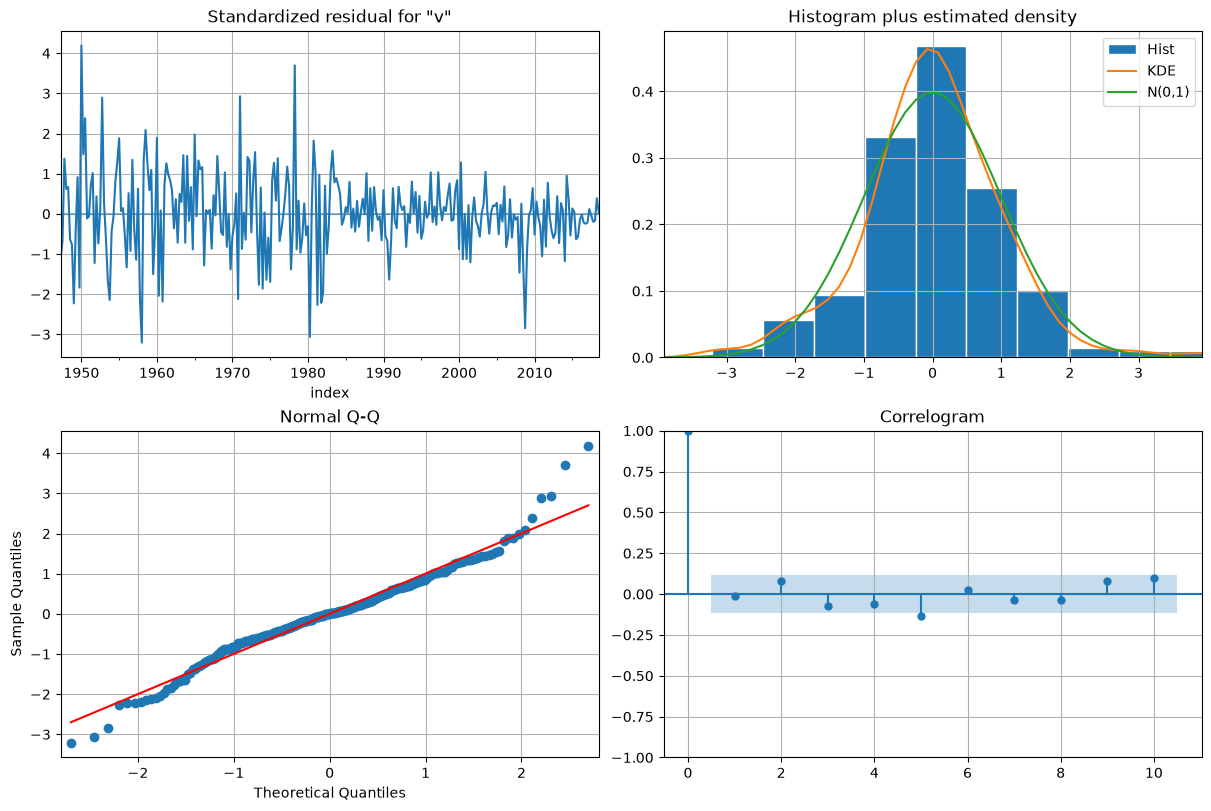

In [11]:
# §B4: diagnóstico de residuos del ARMA
modelo.plot_diagnostics(figsize=(12, 8))
print(sm.stats.acorr_ljungbox(modelo.resid, lags=[10, 20]))
# p-valor > 0.05 -> NO se rechaza ruido blanco -> residuos limpios

        prediccion    IC_inf    IC_sup
2018Q4    0.008154 -0.008860  0.025167
2019Q1    0.007955 -0.010024  0.025935
2019Q2    0.007848 -0.010406  0.026101
2019Q3    0.007790 -0.010544  0.026123


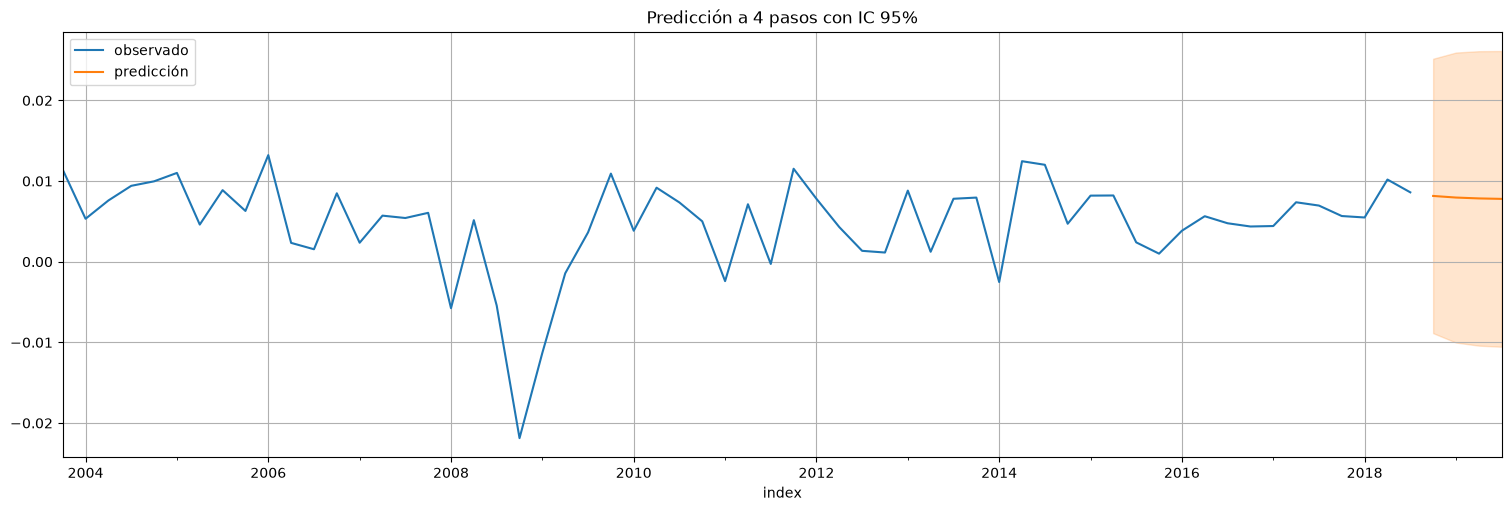

In [12]:
# §B5: predicción con intervalos de confianza
pasos = 4                        # <-- 'el año siguiente': mensual=12, trimestral=4
fc = modelo.get_forecast(pasos)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
print(pd.DataFrame({'prediccion': pred, 'IC_inf': ci.iloc[:, 0], 'IC_sup': ci.iloc[:, 1]}))

ax = w[-60:].plot(label='observado')
pred.plot(ax=ax, label='predicción', color='C1')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='C1', alpha=0.2)
ax.legend()
ax.set_title(f'Predicción a {pasos} pasos con IC 95%');

2018Q4    18824.361245
2019Q1    18974.714244
2019Q2    19124.211665
2019Q3    19273.763054
Freq: Q-DEC, Name: predicted_mean, dtype: float64


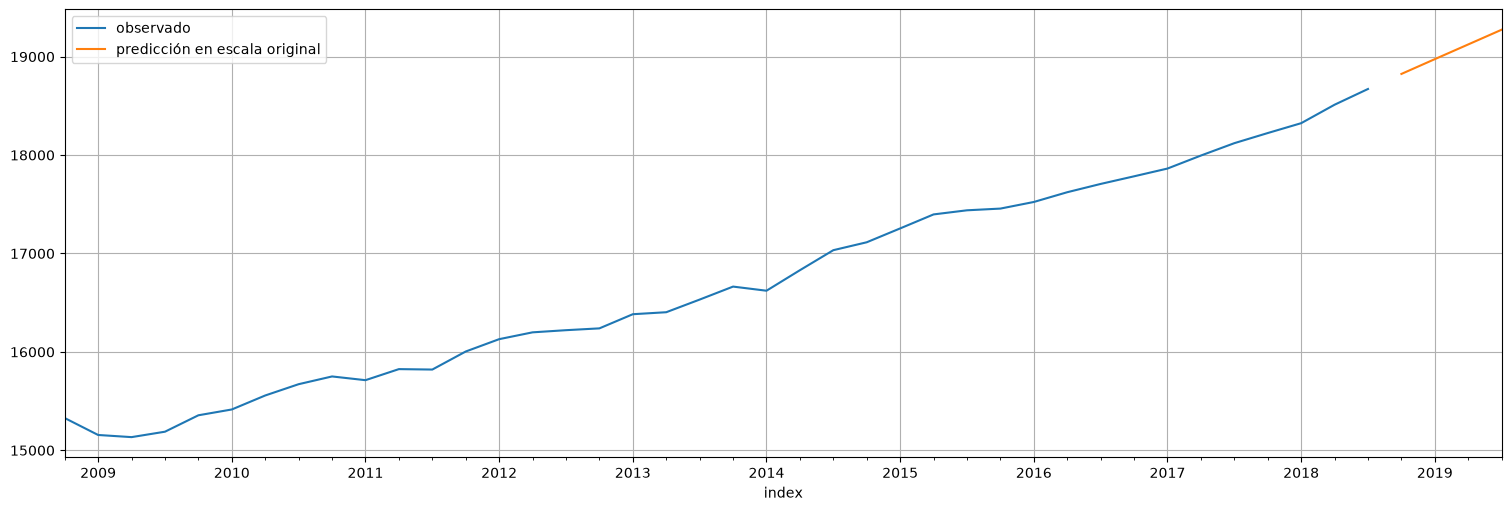

In [13]:
# §B6: deshacer transformaciones para volver a la escala original
# Caso ∇log (lo que predijimos es el crecimiento): acumular + exponenciar desde el último valor
pred_original = np.exp(np.log(z.iloc[-1]) + pred.cumsum())
print(pred_original)

# Caso solo log: pred_original = np.exp(pred)
# Alternativa: ajustar ARIMA(np.log(z), order=(p,1,q)) -> el modelo integra solo y
#              get_forecast ya devuelve log-niveles -> solo falta np.exp

ax = z[-40:].plot(label='observado')
pred_original.plot(ax=ax, label='predicción en escala original', color='C1')
ax.legend();

## §C — Tipo C: dos series, CCF y regresión con lag
*(demo: `lap`, CO → mortalidad respiratoria, semanal)*

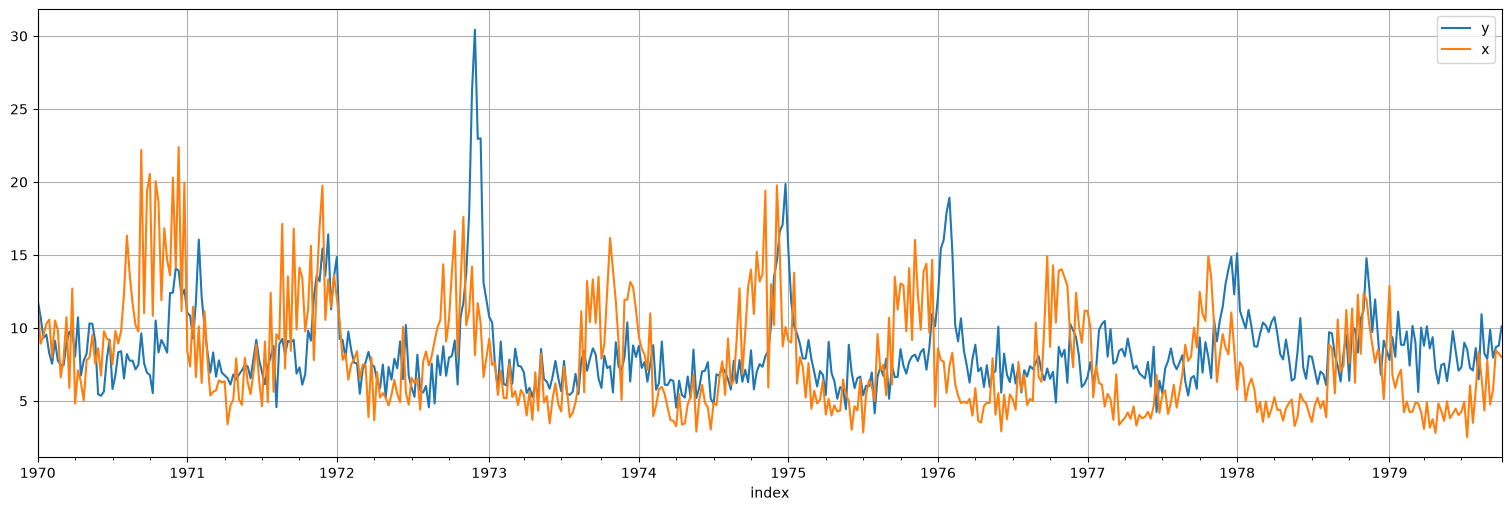

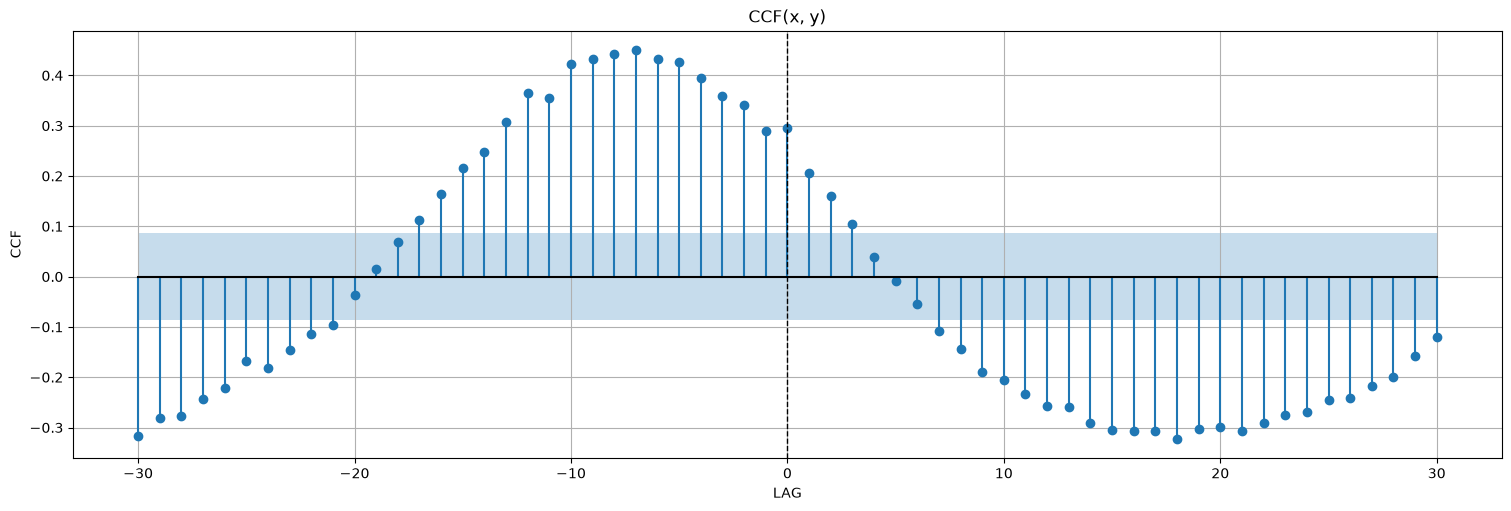

In [14]:
# §C1: graficar ambas series + CCF
xs = astsa.lap['co']        # <-- SERIE EXPLICATIVA (x, la que 'adelanta')
ys = astsa.lap['rmort']     # <-- SERIE A EXPLICAR (y)
# Si piden incrementos: xs = xs.diff().dropna(); ys = ys.diff().dropna()

ax = ys.plot(label='y')
xs.plot(ax=ax, label='x')
ax.legend()
plt.figure()
ccf(xs, ys, max_lag=30)
plt.title('CCF(x, y)');

In [15]:
# §C2: lag de máxima correlación — corr(y_t, x_{t-l})
cors = pd.Series({l: ys.corr(xs.shift(l)) for l in range(0, 13)})
print(cors)
l_opt = int(cors.idxmax())          # usar cors.abs().idxmax() si la correlación fuerte es negativa
print()
print(f'Lag óptimo: l = {l_opt} | corr = {cors[l_opt]:.3f}')

0     0.295821
1     0.290191
2     0.341598
3     0.359201
4     0.396229
5     0.427900
6     0.435108
7     0.452350
8     0.445080
9     0.435299
10    0.425734
11    0.356829
12    0.367312
dtype: float64

Lag óptimo: l = 7 | corr = 0.452


In [16]:
# §C3: regresión y_t = b0 + b1 * x_{t-l}  (shift + dropna ANTES de ols)
datos = pd.DataFrame({'y': ys, 'xlag': xs.shift(l_opt)}).dropna()
fit_lag = ols('y ~ xlag', data=datos).fit()
print(fit_lag.summary().tables[1])
print()
print(f'R2 = {fit_lag.rsquared:.3f} -> explica {100*fit_lag.rsquared:.1f}% de la varianza (R2 = corr^2)')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6412      0.267     21.136      0.000       5.117       6.166
xlag           0.3444      0.030     11.330      0.000       0.285       0.404

R2 = 0.205 -> explica 20.5% de la varianza (R2 = corr^2)


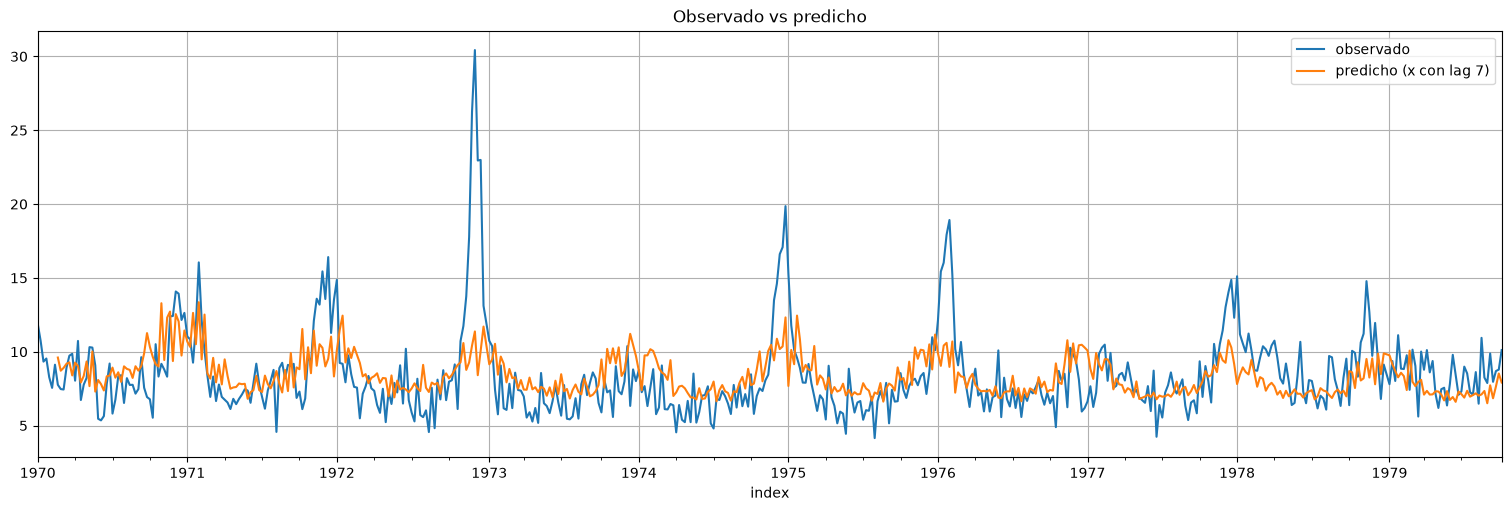

In [17]:
# §C4: observado vs predicho (la predicción arranca l pasos tarde)
ax = ys.plot(label='observado')
fit_lag.fittedvalues.plot(ax=ax, label=f'predicho (x con lag {l_opt})')
ax.legend()
ax.set_title('Observado vs predicho');

## §D — Tipo D: espacio de estados / modelo estructural
*(demo: `log(flu)` mensual con estacionalidad anual)*

In [18]:
# §D1: UnobservedComponents — copiar los argumentos EXACTOS del enunciado
yu = np.log(astsa.flu.squeeze())    # <-- TU SERIE ACÁ

# GOTCHA: plot_components() no soporta PeriodIndex (los datasets astsa vienen así)
# -> convertir a fechas ANTES de ajustar. Si tu serie ya tiene DatetimeIndex, salteá esta línea.
if isinstance(yu.index, pd.PeriodIndex):
    yu.index = yu.index.to_timestamp()

mod_uc = sm.tsa.UnobservedComponents(yu,
                                     level=True,
                                     stochastic_level=True,
                                     seasonal=12,               # período: semanal=7, mensual/anual=12
                                     stochastic_seasonal=True)
res_uc = mod_uc.fit()
print(res_uc.summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
sigma2.level        0.0282      0.002     11.922      0.000       0.024       0.033
sigma2.seasonal  2.481e-11   7.01e-05   3.54e-07      1.000      -0.000       0.000


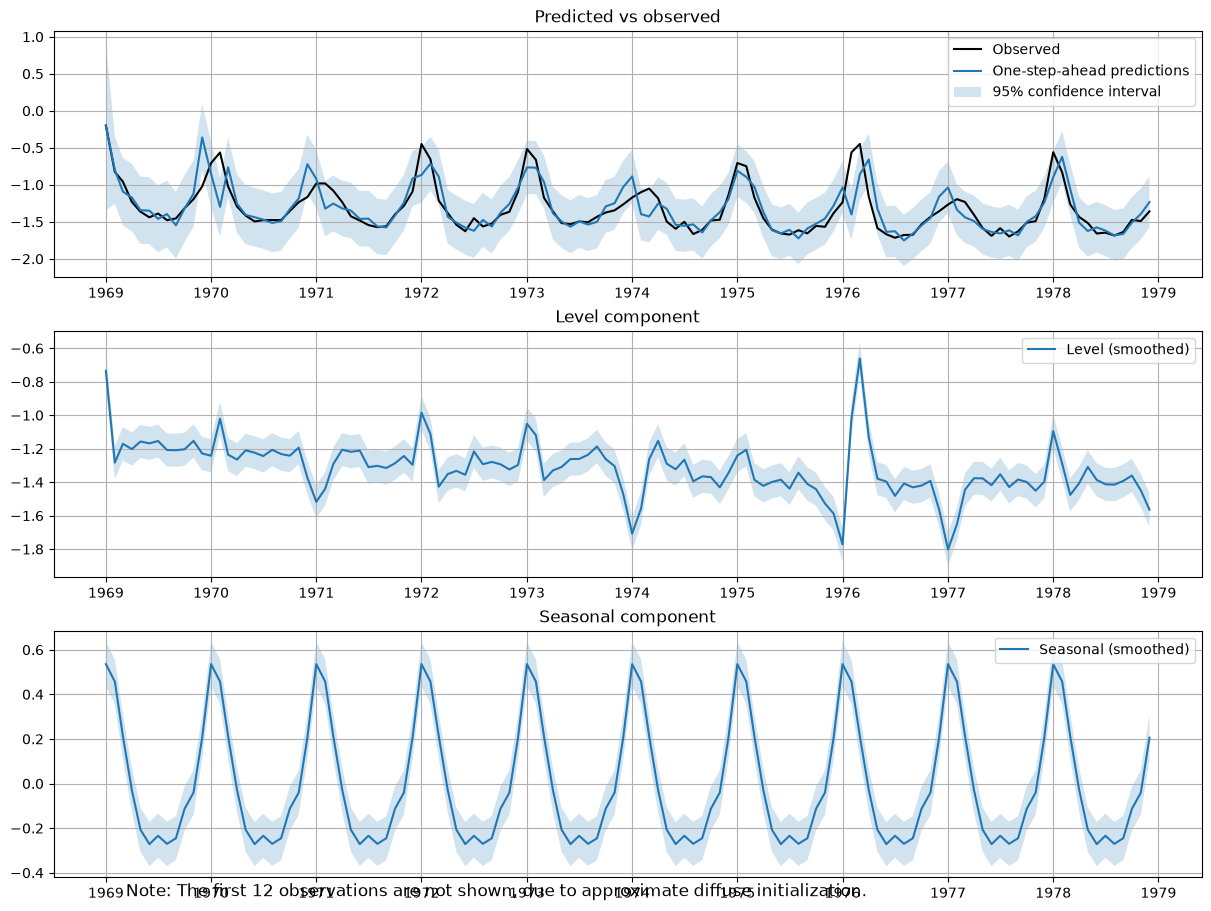

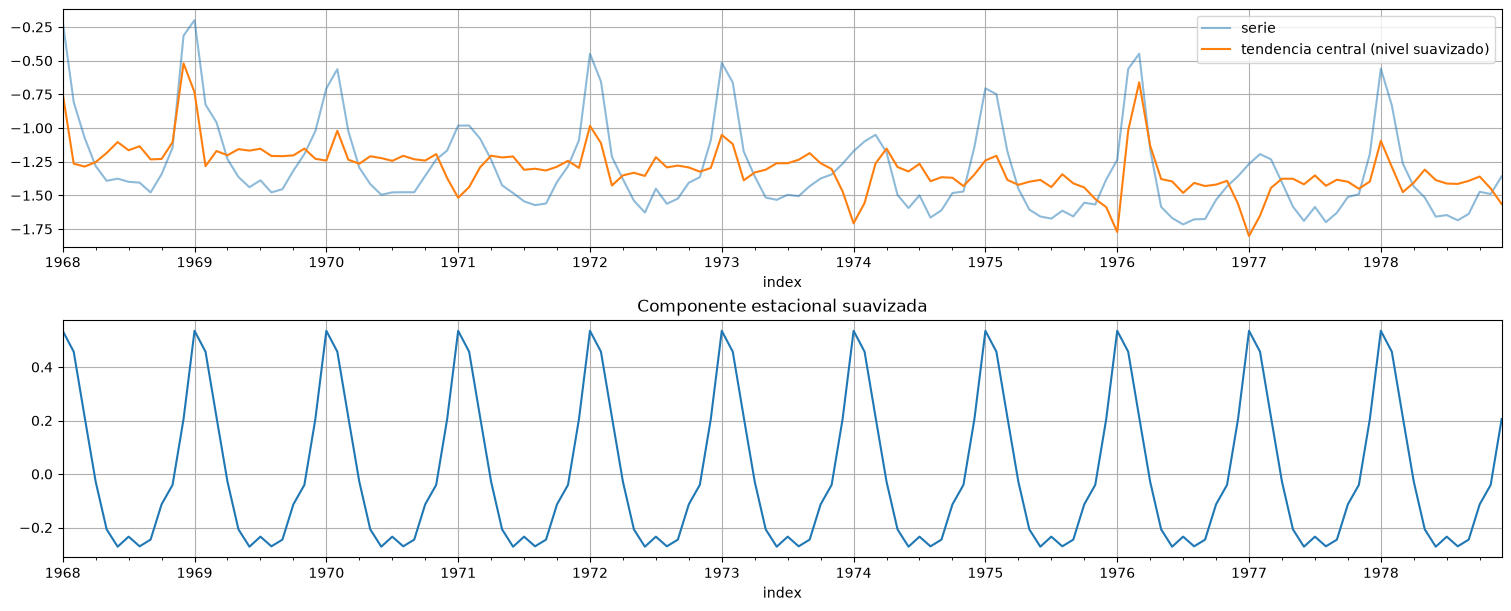

In [19]:
# §D2: graficar componentes (nivel/tendencia y estacionalidad) + predicción
res_uc.plot_components(figsize=(12, 9))

# Acceso directo a las componentes suavizadas:
nivel = pd.Series(res_uc.level['smoothed'], index=yu.index)
estacional = pd.Series(res_uc.seasonal['smoothed'], index=yu.index)

fig, axs = plt.subplots(2, 1, figsize=(15, 6))
yu.plot(ax=axs[0], label='serie', alpha=0.5)
nivel.plot(ax=axs[0], label='tendencia central (nivel suavizado)')
axs[0].legend()
estacional.plot(ax=axs[1], title='Componente estacional suavizada');

## §E — Extras

       lb_stat     lb_pvalue
10  474.048042  1.542034e-95
20  478.193486  1.060703e-88


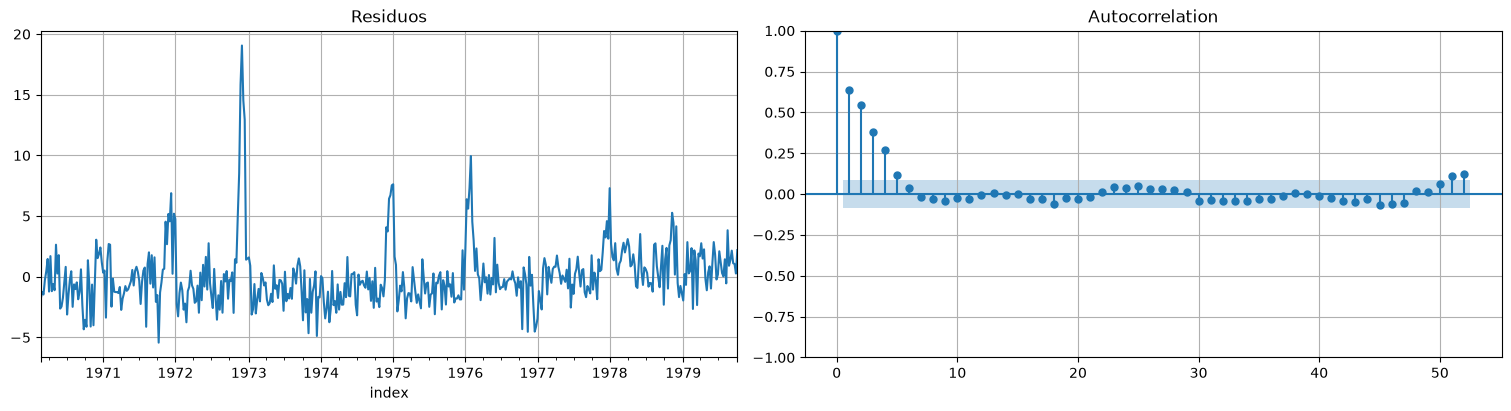

In [20]:
# §E1: análisis de residuos de una regresión (bloque genérico para cualquier ols)
resid = fit_lag.resid               # <-- TUS RESIDUOS ACÁ

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
resid.plot(ax=axs[0], title='Residuos')
plot_acf(resid, lags=52, bartlett_confint=False, ax=axs[1])
print(sm.stats.acorr_ljungbox(resid, lags=[10, 20]))
# Dentro de bandas + p > 0.05 -> ruido blanco. Si no: 'queda información por extraer'

MSE sobre test: 0.000003


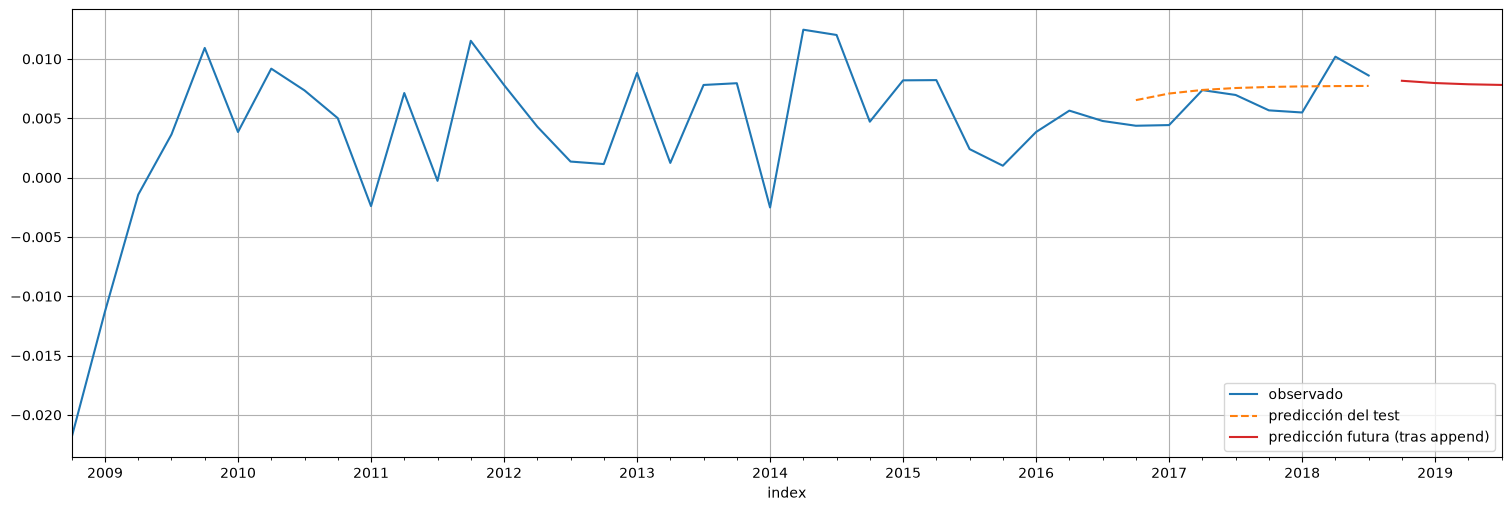

In [21]:
# §E2: train/test + predicción recursiva con fit.append + MSE
serie = np.log(astsa.gdp.squeeze()).diff().dropna()   # <-- TU SERIE ACÁ
k = 8                                                  # tamaño del test
train, test = serie[:-k], serie[-k:]

m_tr = ARIMA(train, order=(1, 0, 1)).fit()
pred_test = m_tr.get_forecast(k).predicted_mean        # predicción 'a ciegas' del bloque test
mse = ((pred_test - test)**2).mean()
print(f'MSE sobre test: {mse:.6f}')

# append: incorpora los datos reales del test SIN reestimar -> permite predecir lo que sigue
m_full = m_tr.append(test)
pred_futuro = m_full.get_forecast(4).predicted_mean

ax = serie[-40:].plot(label='observado')
pred_test.plot(ax=ax, label='predicción del test', style='--')
pred_futuro.plot(ax=ax, label='predicción futura (tras append)', color='C3')
ax.legend();

MSE en escala original: 0.002851


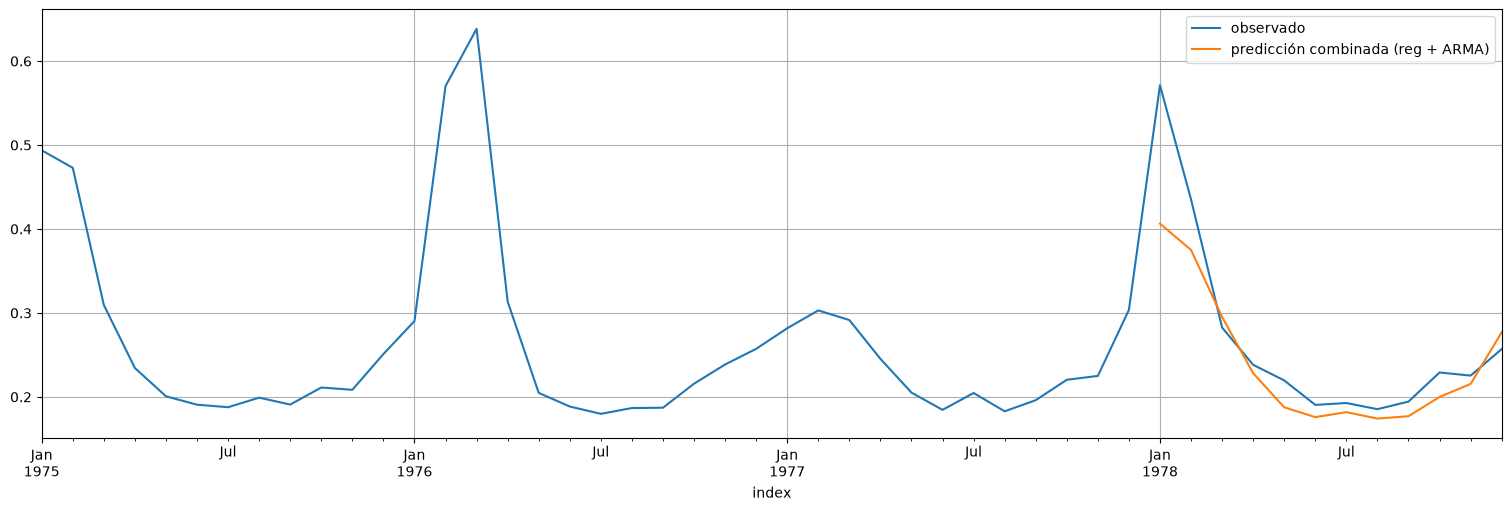

In [22]:
# §E3: patrón 2024-Ej1 completo — regresión (tendencia+dummies) + ARMA sobre residuos
#      + predicción combinada + deshacer el log
yy = np.log(astsa.flu.squeeze())     # <-- serie transformada
k = 12                               # test = último año
n = len(yy)
dfE = pd.DataFrame({'y': yy.values, 't': np.arange(n), 'mes': yy.index.month}, index=yy.index)
df_tr, df_te = dfE.iloc[:-k], dfE.iloc[-k:]

# 1) regresión con tendencia + dummies sobre el train
fit_reg = ols('y ~ t + C(mes)', data=df_tr).fit()

# 2) ARMA sobre los residuos del train
res_tr = fit_reg.resid
m_res = ARIMA(res_tr, order=(1, 0, 0)).fit()

# 3) predicción combinada sobre el test: regresión + ARMA de residuos
pred_reg = fit_reg.predict(df_te)
pred_res = m_res.get_forecast(k).predicted_mean
pred_log = pred_reg + pred_res

# 4) deshacer el log y evaluar
pred_final = np.exp(pred_log)
obs = astsa.flu.squeeze().iloc[-k:]
print(f'MSE en escala original: {((pred_final - obs)**2).mean():.6f}')

ax = astsa.flu.squeeze()[-48:].plot(label='observado')
pred_final.plot(ax=ax, label='predicción combinada (reg + ARMA)', color='C1')
ax.legend();

---
### Recordatorios finales

- **Time-box**: ~⅓ del tiempo por ejercicio; si te trabás > 10 min, escribí la interpretación y seguí.
- **Cada parte cierra con 2–3 oraciones** — plantillas en `guia_rapida.md`.
- Gráficos siempre con título y leyenda.
- 2 modelos candidatos alcanzan; AIC + residuos deciden.